In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("diabetes_unclean.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


##PART 1: PREPROCESSING AND DATA CLEANING (PANDAS)
================================================================================

In [6]:
# 1) Drop the "ID" and "No_Pation" columns
df = df.drop("ID", axis=1)
df.head()

,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [7]:
df = df.drop("No_Pation", axis=1)
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [8]:
df['CLASS'].unique()

<StringArray>
['N', 'N ', 'P', 'Y', 'Y ']
Length: 5, dtype: str

In [9]:
df['CLASS'] = df['CLASS'].replace('N ', 'N')
df['CLASS'] = df['CLASS'].replace('Y ', 'Y')
df['CLASS'].unique()

<StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str

In [10]:
# 2) Display the unique values of the "Gender" column. If there are any misspelled values for 'F' and 'M', correct them
df["Gender"].unique()

<StringArray>
['F', 'M', 'f']
Length: 3, dtype: str

In [11]:
df['Gender'] = df['Gender'].replace('f', 'F')
df['Gender'].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [12]:
# 3) Perform one-hot encoding on all categorical columns except the target variable
# Separate target column
target = df['CLASS']

# Features only
X = df.drop('CLASS', axis=1)

# One-hot encoding
X = pd.get_dummies(X)

# Add target back
df_coded = pd.concat([X, target], axis=1)

df_coded.head()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Gender_F,Gender_M,CLASS
0,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,N
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,False,True,N
2,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,N
3,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,True,False,N
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,False,True,N


In [13]:
# 4) Handle missing values using an appropriate method (drop rows, fill with mean, or
# fill with mode).

df_coded.isna().sum()

AGE         1
Urea        1
Cr          2
HbA1c       3
Chol        2
TG          2
HDL         1
LDL         2
VLDL        1
BMI         0
Gender_F    0
Gender_M    0
CLASS       0
dtype: int64

In [14]:
df_coded = df_coded.fillna(df_coded.mean(numeric_only=True))
df_coded.isna().sum()

AGE         0
Urea        0
Cr          0
HbA1c       0
Chol        0
TG          0
HDL         0
LDL         0
VLDL        0
BMI         0
Gender_F    0
Gender_M    0
CLASS       0
dtype: int64

## PART 2: EXPLORATORY DATA ANALYSIS (VISUALIZATIONS)

### Create the following plots using Matplotlib or Seaborn:

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

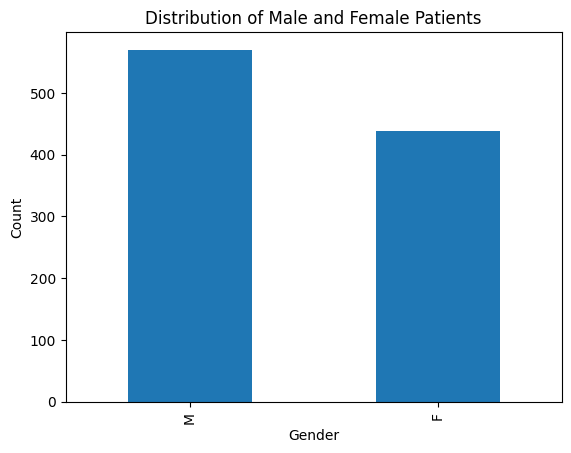

In [16]:
# 1) Bar chart showing the distribution of male and female patients
df['Gender'].value_counts().plot(kind='bar')

plt.title("Distribution of Male and Female Patients")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

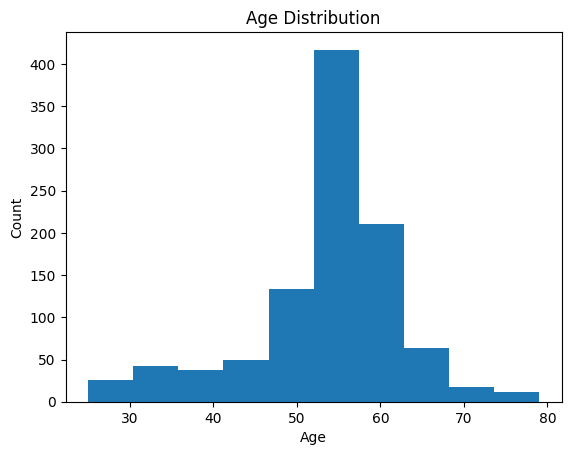

In [17]:
# 2) Histogram of age distribution
df['AGE'].plot(kind='hist')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

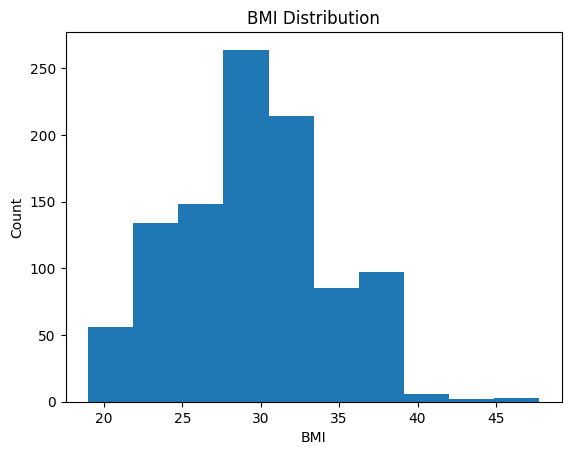

In [18]:
# 3) Histogram of BMI distribution
df['BMI'].plot(kind='hist')

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

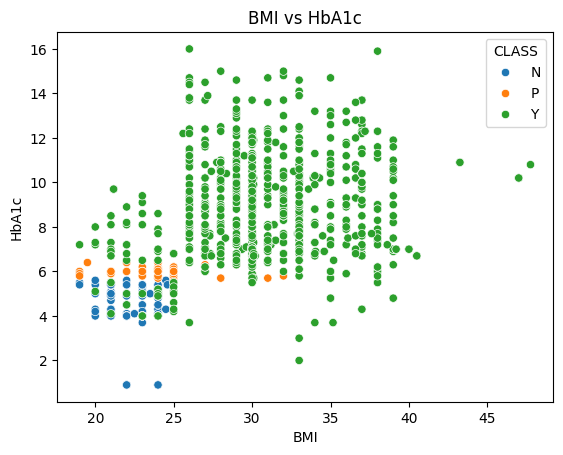

In [19]:
# 4) Scatter plot: BMI vs HbA1c (color-coded by diabetes class)
sns.scatterplot(x='BMI', y='HbA1c', hue='CLASS', data=df)

plt.title("BMI vs HbA1c")
plt.xlabel("BMI")
plt.ylabel("HbA1c")
plt.show()


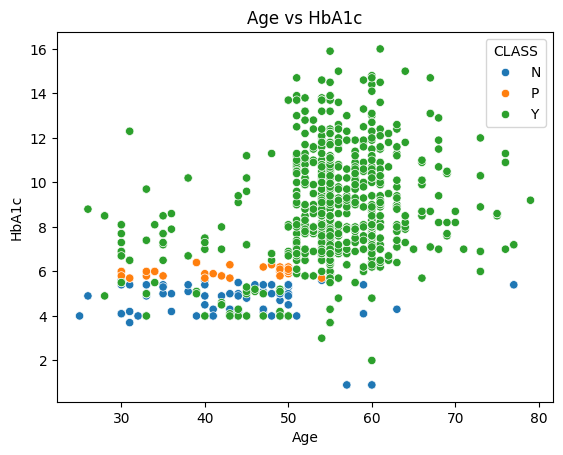

In [20]:
# 5) Scatter plot: Age vs HbA1c (color-coded by diabetes class)
sns.scatterplot(x='AGE', y='HbA1c', hue='CLASS', data=df)

plt.title("Age vs HbA1c")
plt.xlabel("Age")
plt.ylabel("HbA1c")
plt.show()


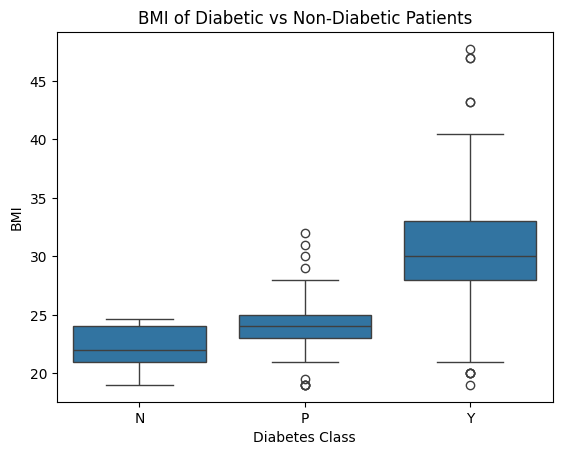

In [21]:
# 6) Box plot comparing BMI of diabetic vs non-diabetic patients
sns.boxplot(x='CLASS', y='BMI', data=df)

plt.title("BMI of Diabetic vs Non-Diabetic Patients")
plt.xlabel("Diabetes Class")
plt.ylabel("BMI")
plt.show()

## PART 3: MODEL TRAINING (SCIKIT-LEARN)

Split data into training (70%) and testing (30%) sets

In [22]:
from sklearn.model_selection import train_test_split

X = df_coded.drop('CLASS', axis=1)
y = df_coded['CLASS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    }

### MODEL 1: Logistic Regression

In [24]:
# Import model
from sklearn.linear_model import LogisticRegression

In [25]:
# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

d:\Desktop\MLOPS_Assignment_1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
# predict
y_pred_log = log_model.predict(X_test)

In [27]:
# Evaluate model
log_results = evaluate_model(y_test, y_pred_log)
log_results

{'Accuracy': 0.9438943894389439,
 'Precision': 0.9392747115519392,
 'Recall': 0.9438943894389439,
 'F1 Score': 0.9397595108348045}

### MODEL 2: SVM

In [28]:
# Import model
from sklearn.svm import SVC

In [29]:
# Train model
svm_model = SVC()
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [30]:
# predict
y_pred_svm = svm_model.predict(X_test)

In [31]:
# Evaluate
svm_results = evaluate_model(y_test, y_pred_svm)
svm_results

d:\Desktop\MLOPS_Assignment_1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'Accuracy': 0.8481848184818482,
 'Precision': 0.7194174863030858,
 'Recall': 0.8481848184818482,
 'F1 Score': 0.7785124941065534}

### MODEL 3: Decision Tree

In [ ]:
# Import model
from sklearn.tree import DecisionTreeClassifier

# Train model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
dt_results = evaluate_model(y_test, y_pred_dt)
dt_results

{'Accuracy': 0.9867986798679867,
 'Precision': 0.9867808402461868,
 'Recall': 0.9867986798679867,
 'F1 Score': 0.9866676877490014}

### MODEL 4: Random Forest

In [33]:
# Import model
from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

# predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_results = evaluate_model(y_test, y_pred_rf)
rf_results

{'Accuracy': 0.9801980198019802,
 'Precision': 0.9803566235112837,
 'Recall': 0.9801980198019802,
 'F1 Score': 0.9793311332681508}

### MODEL 5: KNN

In [34]:
# imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [35]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
# Train model
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [37]:
# predict
y_pred_knn = knn_model.predict(X_test_scaled)

In [38]:
# Evaluate
knn_results = evaluate_model(y_test, y_pred_knn)
knn_results

{'Accuracy': 0.933993399339934,
 'Precision': 0.9395101014763356,
 'Recall': 0.933993399339934,
 'F1 Score': 0.9357408860723778}

## Create a comparison table showing all models' performance

In [39]:
import pandas as pd

results = pd.DataFrame([
    log_results,
    svm_results,
    dt_results,
    rf_results,
    knn_results
], index=[
    "Logistic Regression",
    "SVM",
    "Decision Tree",
    "Random Forest",
    "KNN"
])

results

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.943894,0.939275,0.943894,0.939760
SVM,0.848185,0.719417,0.848185,0.778512
Decision Tree,0.986799,0.986781,0.986799,0.986668
Random Forest,0.980198,0.980357,0.980198,0.979331
KNN,0.933993,0.939510,0.933993,0.935741


THe best performing model is Decision Tree

# PART 4: MODEL SELECTION AND SAVING

In [40]:
best_model = dt_model

In [41]:
# Training column
training_columns = X.columns

In [42]:
# Save model using joblib
import joblib

joblib.dump(best_model, 'diabetes_model.pkl')

['diabetes_model.pkl']

In [43]:
# Save training columns
joblib.dump(training_columns, 'training_columns.pkl')

['training_columns.pkl']